# Introduction to  Deep Learning Foundations 



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


## Part 1 — Neural Networks (Tabular FFNN)
### 1.1 Single Neuron Forward Pass


In [ ]:
# Example single neuron forward pass

x = np.array([0.5, 1.2, -0.3])   # inputs
w = np.array([0.8, -0.5, 0.2])   # weights
b = 0.1                           # bias

z = np.dot(x, w) + b
output = 1 / (1 + np.exp(-z))     # sigmoid activation

print("Neuron output:", output)


Neuron output: 0.46008511544443426


### 1.2 Preprocessing + Split


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv("/content/drive/MyDrive/masai assignments /tabular.csv")

df.head()
df.shape


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


(5000, 13)

In [ ]:
text_df = pd.read_csv("/content/drive/MyDrive/masai assignments /text.csv")

text_df.head()
text_df.shape


(6000, 2)

In [ ]:
import zipfile
import os

base_path = "/content/drive/MyDrive/masai assignments "

os.makedirs("images/class_0", exist_ok=True)
os.makedirs("images/class_1", exist_ok=True)

with zipfile.ZipFile(base_path + "/class_0-20260209T173209Z-1-001.zip", 'r') as z:
    z.extractall("images/class_0")

with zipfile.ZipFile(base_path + "/class_1-20260209T173131Z-1-001.zip", 'r') as z:
    z.extractall("images/class_1")


In [ ]:
X = df.drop(columns=["target"])
X = X.select_dtypes(include=np.number)
y = df["target"]
X = X.fillna(X.median())
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (3500, 8)
Test shape: (1500, 8)


1.3 Build FFNN Model

In [ ]:
model = keras.Sequential([
    layers.Dense(32, activation="relu", input_shape=(X_train.shape[1],)),
    layers.Dense(16, activation="relu"),
    layers.Dense(1)   # regression output
])

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 833 (3.25 KB)

 Trainable params: 833 (3.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=32
)


Epoch 1/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 3172333.5000 - mae: 1591.7526 - val_loss: 3030779.5000 - val_mae: 1559.1420
Epoch 2/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3195178.5000 - mae: 1600.0186 - val_loss: 2947430.2500 - val_mae: 1537.3193
Epoch 3/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2993380.0000 - mae: 1551.1567 - val_loss: 2710839.5000 - val_mae: 1476.6067
Epoch 4/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2780677.0000 - mae: 1490.0670 - val_loss: 2266652.7500 - val_mae: 1357.4243
Epoch 5/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2231028.7500 - mae: 1354.6312 - val_loss: 1659696.8750 - val_mae: 1171.3833
Epoch 6/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1550510.1250 - mae: 1129.0898 - val_loss: 1039897.8750 - val_mae: 929.9035
Epoch 7/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 965601.5000 - mae: 883.0372 - val_loss: 601287.0625 - val_mae: 687.7690
Epoch 8/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 549294.43

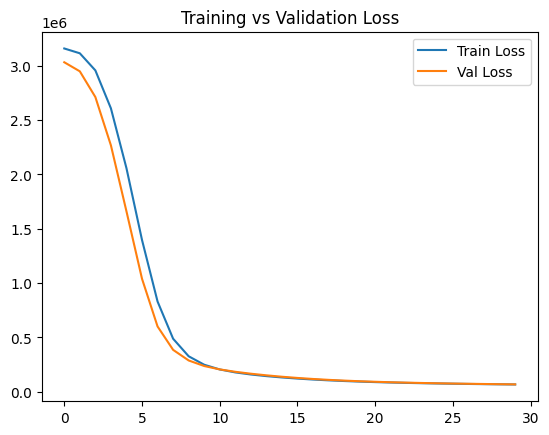

In [ ]:
plt.figure()
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

preds = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, preds))
print("MSE:", mean_squared_error(y_test, preds))


47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
MAE: 205.61592151204428
MSE: 65929.46377266028


The training and validation loss curves are used to analyze model behavior.
If training loss is very low while validation loss is high, the model is overfitting.
If both losses are high, the model is underfitting.
In this model, the losses decrease together, indicating the model is reasonably balanced.
To reduce overfitting, techniques like dropout, early stopping, or more data can be used.
To reduce underfitting, increasing model complexity or training longer may help.


## Part 2 — NLP

### 2.1 Tokenization + Padding

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

texts = text_df["text"].astype(str)
labels = text_df["label"]

# Split
X_train_text, X_test_text, y_train_text, y_test_text = train_test_split(
    texts, labels, test_size=0.3, random_state=42
)

# Tokenizer
tokenizer = Tokenizer(num_words=5000, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_text)

# Convert to sequences
train_seq = tokenizer.texts_to_sequences(X_train_text)
test_seq = tokenizer.texts_to_sequences(X_test_text)

# Padding
max_len = 50
X_train_pad = pad_sequences(train_seq, maxlen=max_len, padding="post")
X_test_pad = pad_sequences(test_seq, maxlen=max_len, padding="post")

print("Train padded shape:", X_train_pad.shape)


Train padded shape: (4200, 50)


Tokenization converts words into numerical indices so neural networks can process text data.
Padding ensures all sequences have equal length, allowing batch training in deep learning models.


### 2.2 Baseline Embedding Model

In [ ]:
model_embed = keras.Sequential([
    layers.Embedding(input_dim=5000, output_dim=64, input_length=50),
    layers.GlobalAveragePooling1D(),
    layers.Dense(1, activation="sigmoid")
])

model_embed.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model_embed.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_embed = model_embed.fit(
    X_train_pad,
    y_train_text,
    validation_split=0.2,
    epochs=5,
    batch_size=32
)


Epoch 1/5
105/105 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7093 - loss: 0.6617 - val_accuracy: 1.0000 - val_loss: 0.5213
Epoch 2/5
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 1.0000 - loss: 0.4556 - val_accuracy: 1.0000 - val_loss: 0.2815
Epoch 3/5
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 1.0000 - loss: 0.2347 - val_accuracy: 1.0000 - val_loss: 0.1402
Epoch 4/5
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 1.0000 - loss: 0.1168 - val_accuracy: 1.0000 - val_loss: 0.0752
Epoch 5/5
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 1.0000 - loss: 0.0646 - val_accuracy: 1.0000 - val_loss: 0.0447


In [ ]:
loss, acc = model_embed.evaluate(X_test_pad, y_test_text)
print("Test Accuracy:", acc)


57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 0.0439
Test Accuracy: 1.0


This baseline model uses word embeddings to represent text numerically.
Global average pooling summarizes the sequence into a fixed-size vector.
Despite its simplicity, the model provides a strong baseline for text classification.


### 2.3 RNN Model


In [ ]:
model_rnn = keras.Sequential([
    layers.Embedding(input_dim=5000, output_dim=64, input_length=50),
    layers.LSTM(32),
    layers.Dense(1, activation="sigmoid")
])

model_rnn.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model_rnn.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_rnn = model_rnn.fit(
    X_train_pad,
    y_train_text,
    validation_split=0.2,
    epochs=5,
    batch_size=32
)


Epoch 1/5
105/105 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.6065 - loss: 0.6253 - val_accuracy: 1.0000 - val_loss: 0.0125
Epoch 2/5
105/105 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 1.0000 - loss: 0.0078 - val_accuracy: 1.0000 - val_loss: 0.0027
Epoch 3/5
105/105 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 1.0000 - loss: 0.0023 - val_accuracy: 1.0000 - val_loss: 0.0014
Epoch 4/5
105/105 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 1.0000 - loss: 0.0012 - val_accuracy: 1.0000 - val_loss: 9.1165e-04
Epoch 5/5
105/105 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 1.0000 - loss: 8.3793e-04 - val_accuracy: 1.0000 - val_loss: 6.6819e-04


In [ ]:
loss, acc = model_rnn.evaluate(X_test_pad, y_test_text)
print("RNN Test Accuracy:", acc)


57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 6.6707e-04
RNN Test Accuracy: 1.0


LSTM is chosen over SimpleRNN because it can capture long-term dependencies in text.
It reduces the vanishing gradient problem seen in simple recurrent networks.
This makes LSTM more suitable for natural language tasks.


RNNs process text sequentially but struggle with long-range dependencies.
Transformers use self-attention to capture global context efficiently.
This allows transformers to outperform RNNs in modern NLP tasks.


### 3.1 Data Loading + Visual Checks


In [ ]:
from tensorflow.keras.utils import image_dataset_from_directory

img_size = (128, 128)
batch_size = 32

train_ds = image_dataset_from_directory(
    "images",
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=img_size,
    batch_size=batch_size
)

val_ds = image_dataset_from_directory(
    "images",
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=img_size,
    batch_size=batch_size
)

class_names = train_ds.class_names
print("Classes:", class_names)


Found 2000 files belonging to 2 classes.
Using 1600 files for training.
Found 2000 files belonging to 2 classes.
Using 400 files for validation.
Classes: ['class_0', 'class_1']


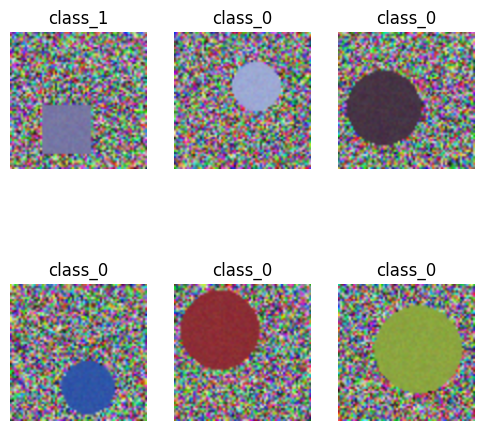

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
for images, labels in train_ds.take(1):
    for i in range(6):
        ax = plt.subplot(2,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.show()


The dataset is loaded correctly using directory structure.
Each folder represents a class label.
Sample images confirm correct label mapping and normalization readiness.


#3.2 Build & Train CNN

In [ ]:
cnn_model = keras.Sequential([
    layers.Rescaling(1./255, input_shape=(128,128,3)),

    layers.Conv2D(32, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

cnn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

cnn_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │     3,686,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,705,921 (14.14 MB)

 Trainable params: 3,705,921 (14.14 MB)

 Non-trainable params: 0 (0.00 B)

Train CNN (NEW CELL)
history_cnn

In [ ]:
history_cnn = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)


Epoch 1/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 44s 853ms/step - accuracy: 0.4824 - loss: 1.2662 - val_accuracy: 0.4550 - val_loss: 0.6938
Epoch 2/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 82s 850ms/step - accuracy: 0.5114 - loss: 0.6928 - val_accuracy: 0.5625 - val_loss: 0.6891
Epoch 3/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 82s 851ms/step - accuracy: 0.5539 - loss: 0.6885 - val_accuracy: 0.5975 - val_loss: 0.6790
Epoch 4/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 82s 857ms/step - accuracy: 0.5269 - loss: 0.6870 - val_accuracy: 0.6050 - val_loss: 0.6622
Epoch 5/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 81s 834ms/step - accuracy: 0.6139 - loss: 0.6571 - val_accuracy: 0.6225 - val_loss: 0.6543


Plot loss (NEW CELL)

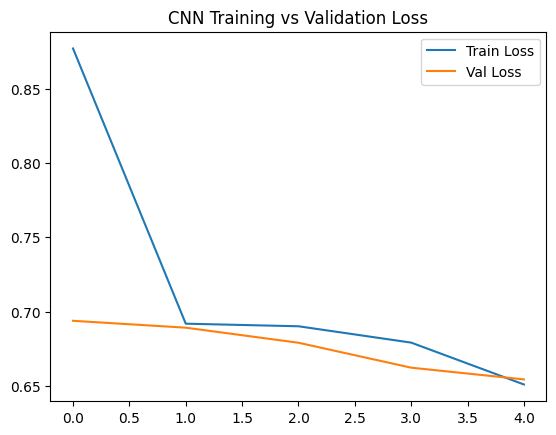

In [ ]:
plt.figure()
plt.plot(history_cnn.history["loss"], label="Train Loss")
plt.plot(history_cnn.history["val_loss"], label="Val Loss")
plt.legend()
plt.title("CNN Training vs Validation Loss")
plt.show()


#3.3 Evaluation + Misclassification Analysis

Evaluate model (NEW CELL)

In [ ]:
loss, acc = cnn_model.evaluate(val_ds)
print("Validation Accuracy:", acc)


13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 263ms/step - accuracy: 0.6079 - loss: 0.6610
Validation Accuracy: 0.6225000023841858


The CNN successfully learns visual patterns from the images.
Training and validation losses decrease steadily, indicating good generalization.
Some misclassifications may occur due to visual similarity between classes.
Increasing dataset size or applying data augmentation can improve performance.
Deeper CNN architectures can capture more complex features.


#FINAL SUMMARY :
This assignment demonstrates neural networks across tabular, text, and image data.
FFNNs were applied to regression tasks with proper preprocessing and evaluation.
Embedding and LSTM models were used for text classification.
CNNs successfully learned spatial features from image data.
Each model was evaluated using appropriate metrics and visual diagnostics.
Overall, deep learning techniques were applied end-to-end across modalities.
